# Лабораторная работа №5. Классификация

#### Цель работы: изучение алгоритмов и методов классификации на практике.

### Вариант 1
#### Набор данных medical_diagnosis.csv


Для начала нам необходимо импортировать все требуемые библиотеки, которые будут использоваться на протяжении всего анализа.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, balanced_accuracy_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## 1. Загрузка набора данных

Далее мы загружаем набор данных из файла medical_diagnosis.csv с помощью функции read_csv из библиотеки pandas и сохраняем его в переменную df. После этого вызываем метод head(), который выводит первые пять строк таблицы, чтобы получить первоначальное представление о структуре данных: какие признаки присутствуют, как они представлены (числовые или категориальные), а также как выглядят целевые метки. Это позволяет убедиться, что данные успешно загружены и не содержат явных сбоев в формате, а также дает общее понимание содержания датасета перед дальнейшей обработкой и анализом.

In [2]:
df = pd.read_csv('medical_diagnosis.csv')
df.head()

,age,sex,BMI,systolic_bp,cholesterol_mg_dl,fasting_glucose_mg_dl,smoking_status,family_history,activity_level,symptom_score,CRP_mg_L,WBC_10e9_L,ECG_result,Disease
0,34,Male,16.8,132.0,196.0,78.0,Current,No,High,0.2,0.58,8.60,Normal,0
1,24,Female,29.2,118.0,182.0,96.0,Current,No,Moderate,3.2,2.72,6.54,Normal,0
2,19,Female,16.5,121.0,268.0,101.0,Current,No,Moderate,3.8,0.18,6.61,Normal,0
3,89,Female,15.4,117.0,136.0,96.0,Never,No,Low,2.6,1.83,5.67,Normal,0
4,66,Male,16.7,82.0,241.0,126.0,Former,No,Moderate,3.5,1.16,2.66,Normal,0


## 2. Предварительная обработка данных

После загрузки данных мы приступаем к их предварительной обработке. Сначала выполняется проверка наличия пропущенных значений с помощью метода isnull().sum(), и выясняется, что в данном наборе данных отсутствуют пропуски - все признаки заполнены полностью. Несмотря на это, код предусматривает стратегию заполнения пропусков медианными значениями для числовых переменных, таких как возраст, ИМТ, систолическое давление и другие биомаркеры, что является хорошей практикой на случай работы с другими, менее чистыми датасетами.

Затем осуществляется кодирование категориальных переменных - пол, статус курения, семейный анамнез, уровень физической активности и результат ЭКГ - с помощью метода get_dummies, который преобразует их в набор бинарных (фиктивных) признаков, исключая первый столбец для избежания мультиколлинеарности (параметр drop_first=True).

In [3]:
print("Предварительная обработка данных:")
print("\n1. Проверка пропущенных значений:")
print(df.isnull().sum())

numeric_cols = ['age', 'BMI', 'systolic_bp', 'cholesterol_mg_dl', 'fasting_glucose_mg_dl', 'symptom_score', 'CRP_mg_L', 'WBC_10e9_L']
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("\n2. После заполнения пропусков:")
print(df.isnull().sum().sum(), "пропущенных значений осталось")

print("\n3. Кодирование категориальных переменных")
categorical_cols = ['sex', 'smoking_status', 'family_history', 'activity_level', 'ECG_result']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\n4. Информация после обработки:")
print(f"Размер данных: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")
print(f"\nРаспределение целевой переменной Disease:")
print(df['Disease'].value_counts())

Предварительная обработка данных:

1. Проверка пропущенных значений:
age                      0
sex                      0
BMI                      0
systolic_bp              0
cholesterol_mg_dl        0
fasting_glucose_mg_dl    0
smoking_status           0
family_history           0
activity_level           0
symptom_score            0
CRP_mg_L                 0
WBC_10e9_L               0
ECG_result               0
Disease                  0
dtype: int64

2. После заполнения пропусков:
0 пропущенных значений осталось

3. Кодирование категориальных переменных

4. Информация после обработки:
Размер данных: (3031, 17)
Колонки: ['age', 'BMI', 'systolic_bp', 'cholesterol_mg_dl', 'fasting_glucose_mg_dl', 'symptom_score', 'CRP_mg_L', 'WBC_10e9_L', 'Disease', 'sex_Male', 'smoking_status_Former', 'smoking_status_Never', 'family_history_Yes', 'activity_level_Low', 'activity_level_Moderate', 'ECG_result_Normal', 'ECG_result_ST-T abnormality']

Распределение целевой переменной Disease:
Disease
0 

После обработки выводится информация о финальной структуре данных: их размерность и список всех столбцов. Особенно важно обратить внимание на распределение целевой переменной Disease: в датасете наблюдается сильный дисбаланс классов - 2982 пациента без заболевания и всего 49 с заболеванием. Такое распределение указывает на то, что любые метрики точности (accuracy) могут вводить в заблуждение, поскольку модель, всегда предсказывающая отсутствие болезни, достигнет высокой точности, но будет бесполезной на практике. Это требует особого подхода при выборе метрик оценки (например, recall, F1-score, balanced accuracy) и, возможно, применения методов балансировки классов.

## 3. Выделение целевой переменной и построение матрицы диаграмм рассеяния

Далее мы разделяем подготовленный датасет на матрицу признаков X и вектор целевой переменной y, удаляя из исходной таблицы столбец 'Disease', который и представляет собой нашу целевую метку.

In [4]:
X = df.drop('Disease', axis=1)
y = df['Disease']

print(f"Матрица признаков X содержит {X.shape[0]} строк и {X.shape[1]} столбцов")
print(f"Вектор целевой переменной y содержит {y.shape[0]} значений")
print(f"\nРаспределение классов:")
print(f"Пациентов без заболевания (0): {sum(y == 0)}")
print(f"Пациентов с заболеванием (1): {sum(y == 1)}")
print(f"Доля пациентов с заболеванием: {sum(y == 1)/len(y)*100:.1f}%")

Матрица признаков X содержит 3031 строк и 16 столбцов
Вектор целевой переменной y содержит 3031 значений

Распределение классов:
Пациентов без заболевания (0): 2982
Пациентов с заболеванием (1): 49
Доля пациентов с заболеванием: 1.6%


В результате матрица X содержит 3031 строку и 16 признаков - это все закодированные и обработанные предикторы, включая как числовые, так и бинарные категориальные переменные. Вектор y состоит из тех же 3031 значения и отражает наличие (1) или отсутствие (0) заболевания у пациента.

Анализ распределения классов подтверждает ранее выявленный сильный дисбаланс: заболевание выявлено всего у 49 из 3031 пациента, что составляет лишь 1,6% от общего объема выборки. Такая пропорция делает задачу классификации крайне несбалансированной, где доминирующий класс (отсутствие болезни) подавляет редкий, но клинически важный класс (наличие болезни).

Для визуального анализа взаимосвязей между числовыми признаками и целевой переменной мы строим матрицу диаграмм рассеяния с помощью seaborn.pairplot, включая только восемь непрерывных признаков: возраст, ИМТ, систолическое давление, уровень холестерина, глюкозы натощак, балл симптомов, СРБ и лейкоциты. Каждый график в матрице показывает распределение пары признаков, а точки окрашены в синий цвет для пациентов без заболевания (класс 0) и в красный - для пациентов с заболеванием (класс 1). Диагональные графики представляют плотности распределения каждого признака отдельно для обоих классов, что позволяет оценить их различия.

<Figure size 2000x2000 with 0 Axes>

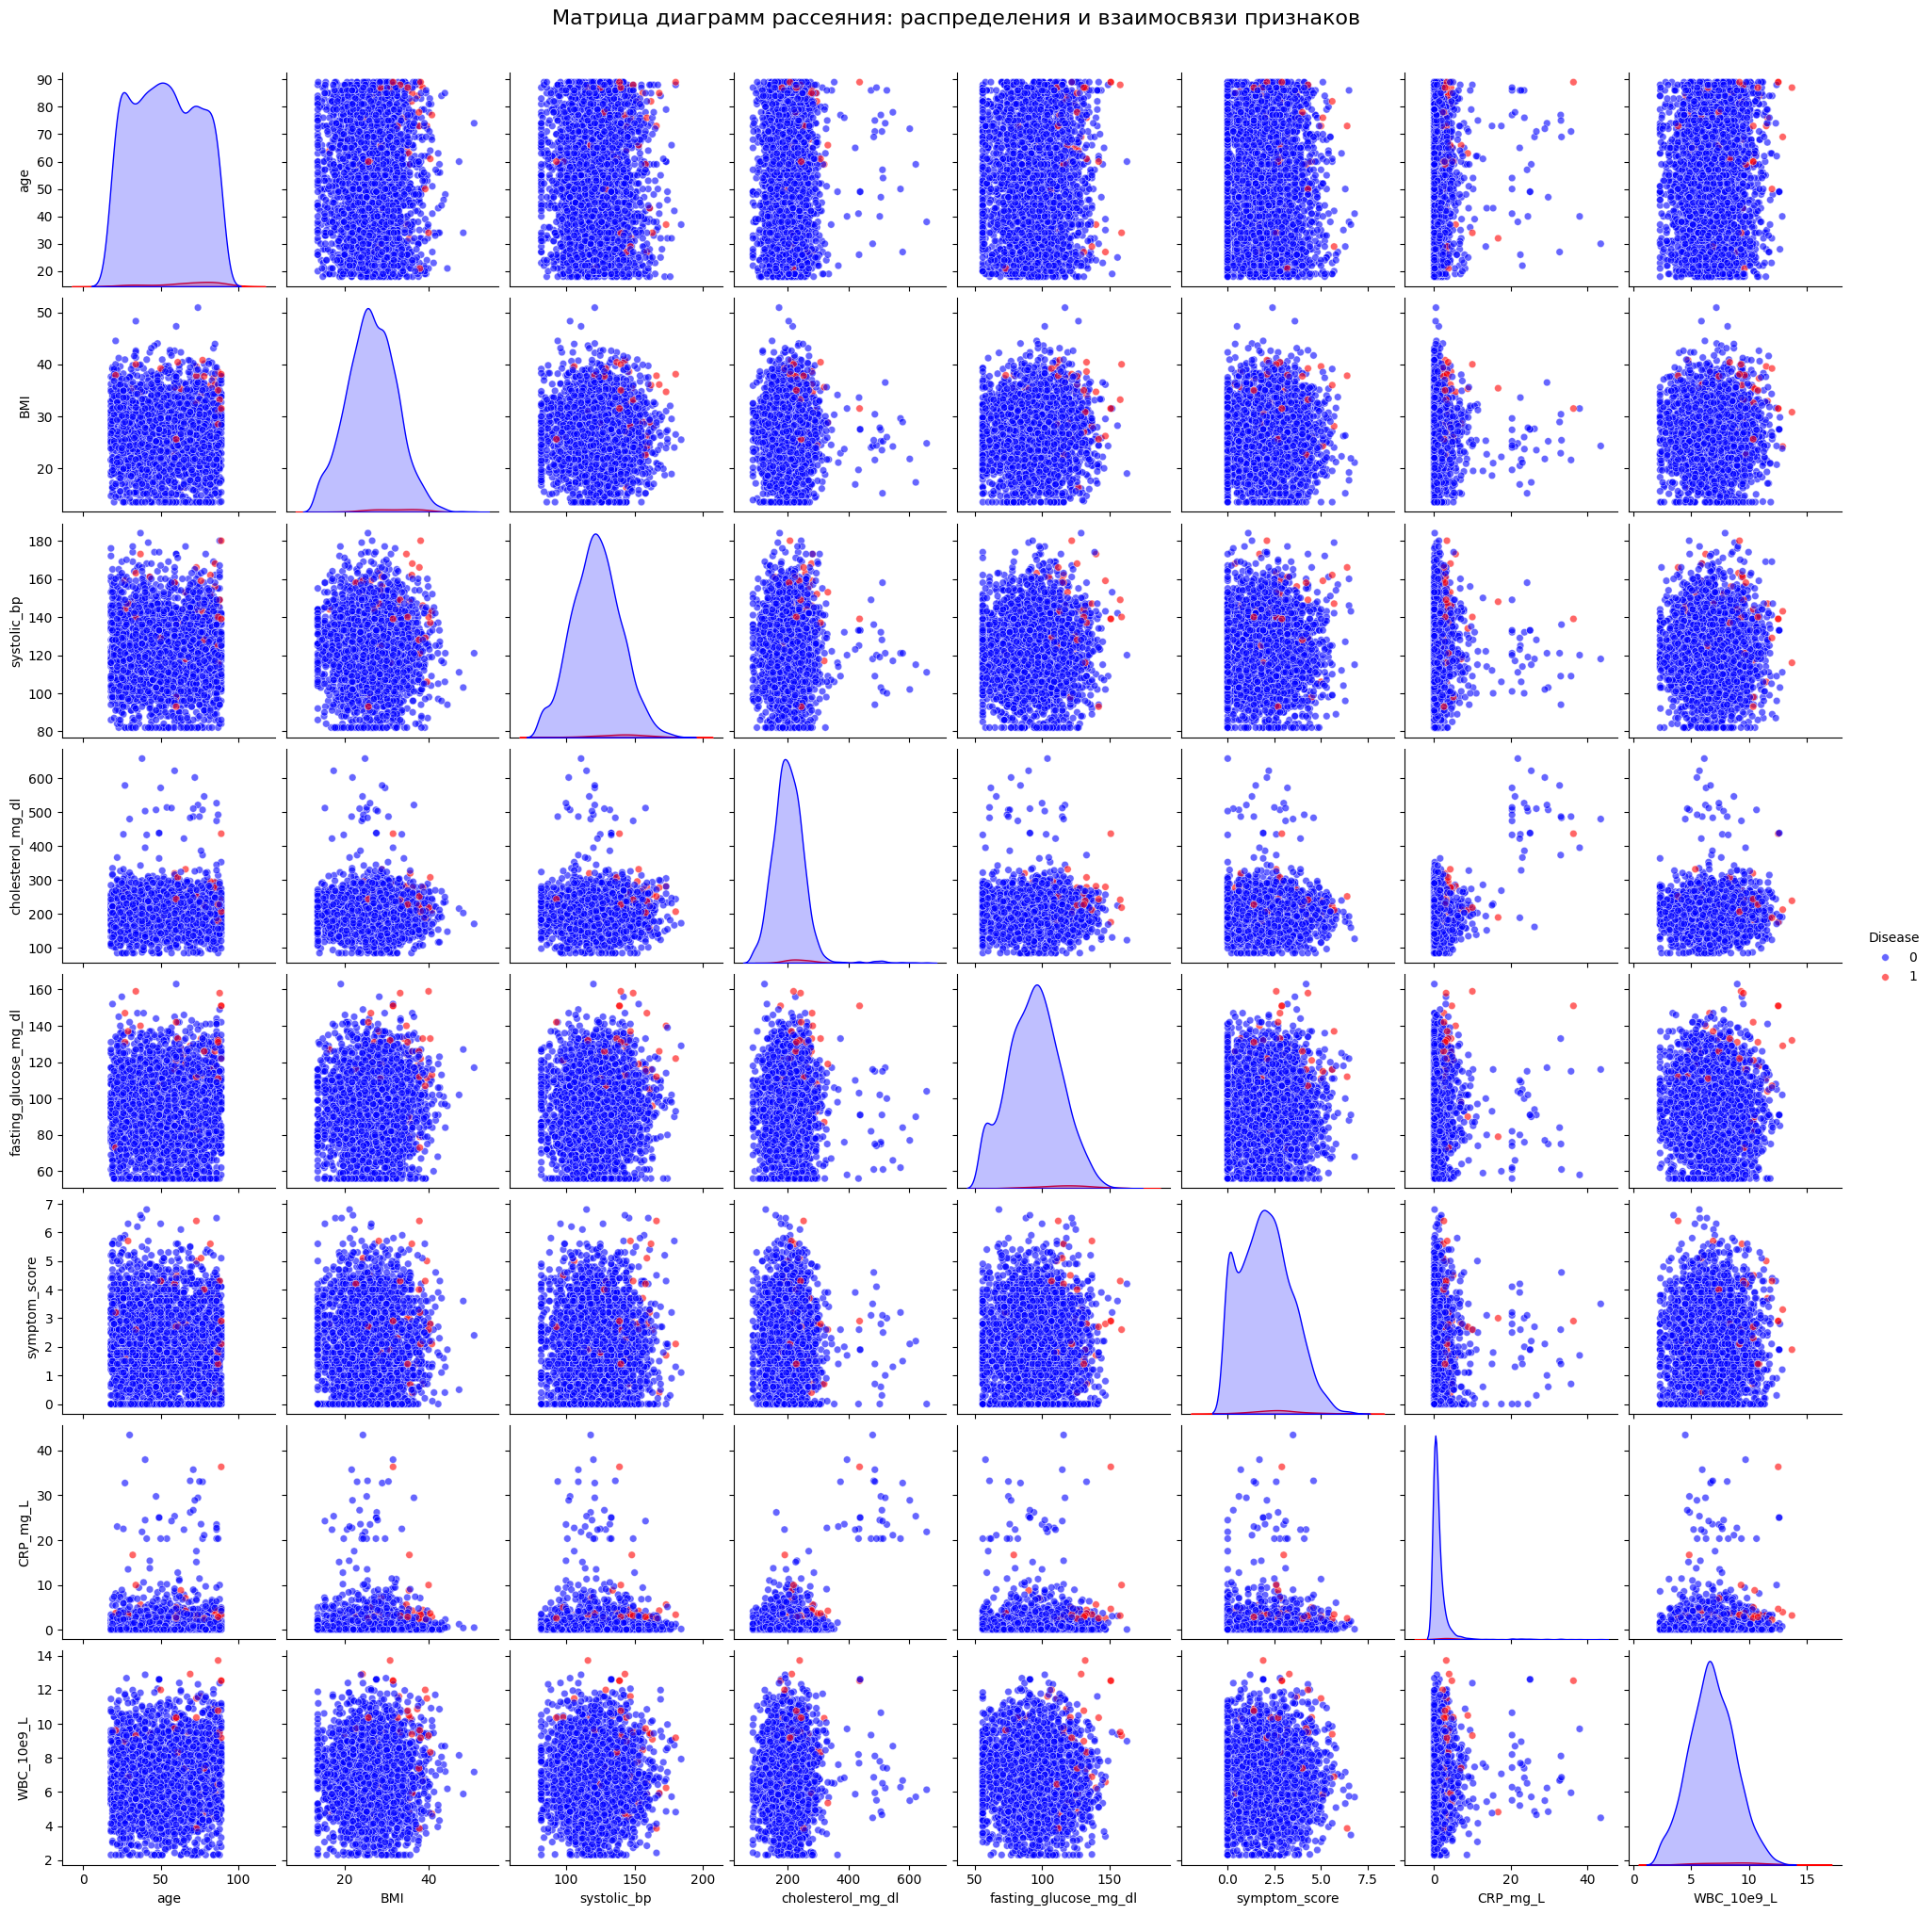

In [5]:
numeric_features = ['age', 'BMI', 'systolic_bp', 'cholesterol_mg_dl', 'fasting_glucose_mg_dl', 'symptom_score', 'CRP_mg_L', 'WBC_10e9_L']

plt.figure(figsize=(20, 20))
sns.pairplot(df[numeric_features + ['Disease']],
             hue='Disease',
             palette={0: 'blue', 1: 'red'},
             diag_kind='kde',
             plot_kws={'alpha': 0.6, 's': 30})
plt.suptitle('Матрица диаграмм рассеяния: распределения и взаимосвязи признаков', y=1.02, fontsize=16)
plt.show()

Анализ визуализации показывает, что большинство признаков имеют похожие распределения у здоровых и больных пациентов, что указывает на слабую дискриминационную способность отдельных параметров. Тем не менее, можно заметить некоторые тенденции: например, пациенты с заболеванием (красные точки) чаще встречаются в верхних квантилях таких признаков, как симптомный балл, уровень СРБ и лейкоцитов, что может свидетельствовать о связи этих маркеров с наличием болезни. Также видно, что данные содержат выбросы, особенно в показателях холестерина и СРБ, что требует внимания при дальнейшей обработке. В целом, визуализация подтверждает, что задача классификации будет сложной из-за значительного перекрытия распределений и малого числа положительных случаев.

## 4. Разделение и стандартизация данных

После завершения предварительной обработки и анализа данных мы разделяем набор на обучающую и тестовую выборки с помощью функции train_test_split. При этом мы задаем размер тестовой части в 30% от общего объема данных, фиксируем random_state для воспроизводимости результатов и используем параметр stratify=y, чтобы сохранить исходное соотношение классов в обеих подвыборках.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Тренировочная выборка: {X_train.shape[0]} записей")
print(f"Тестовая выборка: {X_test.shape[0]} записей")
print(f"\nРаспределение классов в тренировочной выборке:")
print(f"Класс 0: {sum(y_train == 0)} ({sum(y_train == 0)/len(y_train)*100:.1f}%)")
print(f"Класс 1: {sum(y_train == 1)} ({sum(y_train == 1)/len(y_train)*100:.1f}%)")
print(f"\nРаспределение классов в тестовой выборке:")
print(f"Класс 0: {sum(y_test == 0)} ({sum(y_test == 0)/len(y_test)*100:.1f}%)")
print(f"Класс 1: {sum(y_test == 1)} ({sum(y_test == 1)/len(y_test)*100:.1f}%)")

Тренировочная выборка: 2121 записей
Тестовая выборка: 910 записей

Распределение классов в тренировочной выборке:
Класс 0: 2087 (98.4%)
Класс 1: 34 (1.6%)

Распределение классов в тестовой выборке:
Класс 0: 895 (98.4%)
Класс 1: 15 (1.6%)


В результате получаем 2121 запись в обучающей выборке (из них 34 случая заболевания) и 910 записей в тестовой (15 случаев заболевания). Такое разделение позволяет корректно обучать модели и оценивать их качество, не допуская искажений из-за неравномерного распределения меток. Однако даже после стратификации количество положительных примеров остается крайне малым, что создает серьезные вызовы для машинного обучения: модели могут не уловить характерные паттерны заболевания или переобучиться на шум, особенно если не использовать методы, устойчивые к дисбалансу классов.

После разделения данных на обучающую и тестовую выборки мы проводим стандартизацию числовых признаков с помощью StandardScaler из библиотеки scikit-learn. Этот шаг необходим, поскольку многие алгоритмы машинного обучения - особенно такие, как KNN и логистическая регрессия - чувствительны к масштабу признаков. Мы применяем fit_transform только к обучающей выборке, чтобы вычислить среднее и стандартное отклонение, а затем используем transform (без повторного обучения) на тестовой выборке, чтобы избежать утечки информации из теста в обучение.

In [7]:
numeric_features = ['age', 'BMI', 'systolic_bp', 'cholesterol_mg_dl', 'fasting_glucose_mg_dl', 'symptom_score', 'CRP_mg_L', 'WBC_10e9_L']

scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

print(f"\nПервые 3 строки тренировочных данных после стандартизации:")
print(X_train[numeric_features].head(3))
print(f"\nСредние значения признаков после стандартизации (должны быть близки к 0):")
print(X_train[numeric_features].mean().round(3))
print(f"\nСтандартные отклонения (должны быть близки к 1):")
print(X_train[numeric_features].std().round(3))


Первые 3 строки тренировочных данных после стандартизации:
           age       BMI  systolic_bp  cholesterol_mg_dl  \
428  -1.437398  0.844524    -0.289430          -1.011259   
2828  0.677033 -2.205765     1.009609           0.926931   
2049  0.052315  0.384425    -0.007030           1.144298   

      fasting_glucose_mg_dl  symptom_score  CRP_mg_L  WBC_10e9_L  
428               -1.246935       0.066785 -0.091345   -0.255510  
2828              -0.433432      -0.229710 -0.395832   -2.245201  
2049              -0.077524       0.808021 -0.395832   -0.144692  

Средние значения признаков после стандартизации (должны быть близки к 0):
age                      0.0
BMI                     -0.0
systolic_bp             -0.0
cholesterol_mg_dl        0.0
fasting_glucose_mg_dl    0.0
symptom_score           -0.0
CRP_mg_L                 0.0
WBC_10e9_L              -0.0
dtype: float64

Стандартные отклонения (должны быть близки к 1):
age                      1.0
BMI                      1.0
s

Результаты показывают, что после стандартизации средние значения всех числовых признаков в обучающей выборке стали равны нулю (с точностью до машинного округления), а стандартные отклонения - единице, что подтверждает корректность преобразования. Первые три строки стандартизированных данных демонстрируют, как исходные значения были приведены к единому масштабу: например, отрицательные значения возраста указывают на то, что пациент моложе среднего, а положительные - старше. Такое приведение признаков к сопоставимому диапазону улучшает сходимость и стабильность моделей, особенно тех, что опираются на расстояния или градиенты, и позволяет алгоритмам более объективно оценивать вклад каждого признака в предсказание.

## 5. Обучение моделей

На следующем этапе мы обучаем четыре различных классификатора, каждый из которых представляет разный подход к решению задачи бинарной классификации. Для учета сильного дисбаланса классов во всех моделях, где это возможно, задается параметр class_weight='balanced', который автоматически корректирует веса классов обратно пропорционально их частоте в обучающих данных - это помогает моделям уделять больше внимания редкому положительному классу.

Сначала обучается K-ближайших соседей (KNN) с числом соседей, равным 5. Эта модель не требует явного указания весов классов, так как она принимает решения на основе локальной окрестности, но её эффективность в условиях дисбаланса может быть ограничена.

In [8]:
models = {}

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
models['KNN'] = knn


 Далее обучается дерево решений с ограничением глубины до 5 уровней и включённой балансировкой классов, что снижает риск переобучения и помогает выявить значимые расщепления, учитывающие редкие случаи.

In [9]:
dtree = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
dtree.fit(X_train, y_train)
models['Decision Tree'] = dtree

Затем применяется логистическая регрессия с увеличенным количеством итераций (max_iter=1000) для гарантированной сходимости, также с балансировкой классов. Несмотря на свою простоту, логистическая регрессия часто служит надёжной базовой моделью в медицинских задачах благодаря интерпретируемости коэффициентов.

In [10]:
logreg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logreg.fit(X_train, y_train)
models['Logistic Regression'] = logreg

Наконец, обучается случайный лес - ансамблевый метод на основе множества деревьев, также с ограничением глубины и балансировкой классов, что делает его особенно подходящим для несбалансированных данных и позволяет добиться более устойчивых предсказаний за счёт усреднения множества слабых моделей.

In [11]:
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
models['Random Forest'] = rf

Все обученные модели сохраняются в словарь models для последующего сравнения их качества на тестовой выборке.

## 6. Оценка моделей: метрики

После обучения всех моделей мы оцениваем их производительность на тестовой выборке, используя набор метрик, подходящих для несбалансированных данных. Для каждой модели вычисляются точность (Accuracy), прецизионность (Precision), полнота (Recall), сбалансированная точность (Balanced Accuracy) и F1-мера.

In [12]:
results = []

for model_name, model in models.items():
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'Balanced Accuracy': balanced_acc,
        'F1-score': f1
    })

    print(f"\n{model_name}:")
    print(f"  Accuracy:           {accuracy:.4f}")
    print(f"  Precision:          {precision:.4f}")
    print(f"  Recall:             {recall:.4f}")
    print(f"  Balanced Accuracy:  {balanced_acc:.4f}")
    print(f"  F1-score:           {f1:.4f}")


KNN:
  Accuracy:           0.9835
  Precision:          0.0000
  Recall:             0.0000
  Balanced Accuracy:  0.5000
  F1-score:           0.0000

Decision Tree:
  Accuracy:           0.9341
  Precision:          0.1642
  Recall:             0.7333
  Balanced Accuracy:  0.8354
  F1-score:           0.2683

Logistic Regression:
  Accuracy:           0.9011
  Precision:          0.1212
  Recall:             0.8000
  Balanced Accuracy:  0.8514
  F1-score:           0.2105

Random Forest:
  Accuracy:           0.9846
  Precision:          0.5263
  Recall:             0.6667
  Balanced Accuracy:  0.8283
  F1-score:           0.5882


Результаты показывают, что KNN полностью проваливается в обнаружении пациентов с заболеванием: его precision, recall и F1-score равны нулю, несмотря на высокую общую точность (98.35%), что объясняется его склонностью предсказывать только доминирующий класс. Это типичная ловушка при использовании accuracy в условиях дисбаланса.

Дерево решений демонстрирует гораздо более осмысленные результаты: оно обнаруживает 73.3% реальных случаев болезни (высокий recall), но при этом лишь 16.4% его положительных предсказаний оказываются верными (низкая precision), что может приводить к большому числу ложных тревог. Тем не менее, сбалансированная точность (83.5%) и F1-score (0.268) указывают на приемлемую способность модели работать с обоими классами.

Логистическая регрессия показывает еще более высокий recall - 80%, что особенно ценно в медицинском контексте, где важно не пропустить больных, однако её precision падает до 12.1%, а F1-score - до 0.211.

Лучшие результаты демонстрирует случайный лес: он не только сохраняет высокую общую точность (98.46%), но и достигает значительно более сбалансированного поведения - его precision (52.6%) и recall (66.7%) находятся на приемлемом уровне, а F1-score (0.588) заметно превосходит остальные модели. Это говорит о том, что ансамблевый подход эффективно справляется с дисбалансом и способен выявлять сложные паттерны, характерные для редкого класса, при этом сохраняя разумный уровень надёжности положительных предсказаний. Следовательно, случайный лес можно считать наиболее подходящей моделью для данной задачи.

## 7. Матрицы неточностей (Confusion Matrix)

Для более наглядного понимания поведения каждой модели мы строим матрицы неточностей (confusion matrices) - визуализации, показывающие, как часто модель правильно или неправильно классифицирует каждый из двух классов. Каждая матрица содержит четыре ячейки: истинно положительные (TP), ложно положительные (FP), ложно отрицательные (FN) и истинно отрицательные (TN).

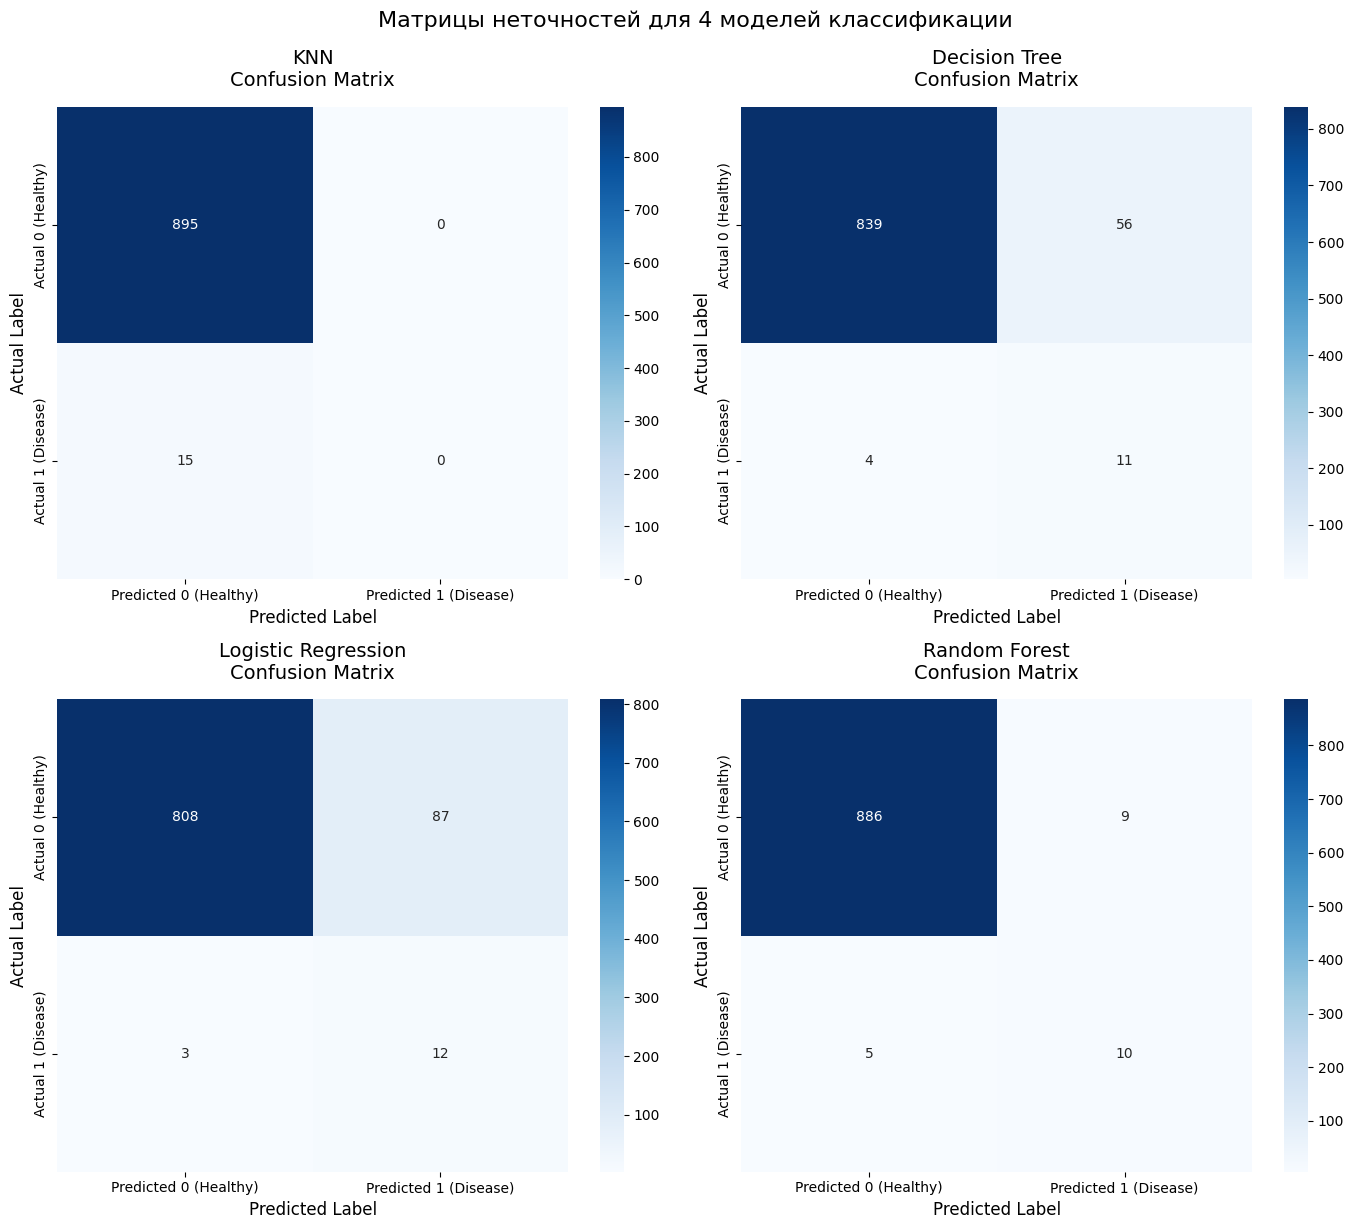

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

model_names = list(models.keys())

for idx, (model_name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0 (Healthy)', 'Predicted 1 (Disease)'],
                yticklabels=['Actual 0 (Healthy)', 'Actual 1 (Disease)'],
                ax=axes[idx])

    axes[idx].set_title(f'{model_name}\nConfusion Matrix', fontsize=14, pad=15)
    axes[idx].set_xlabel('Predicted Label', fontsize=12)
    axes[idx].set_ylabel('Actual Label', fontsize=12)

plt.tight_layout()
plt.suptitle('Матрицы неточностей для 4 моделей классификации', fontsize=16, y=1.02)
plt.show()

Анализ матриц подтверждает выводы, сделанные на основе метрик. Модель KNN предсказывает только здоровых пациентов (все 15 больных были ошибочно отнесены к классу 0), что объясняет её нулевой recall и precision. Дерево решений и логистическая регрессия демонстрируют заметное количество ложноположительных результатов - 56 и 87 соответственно - но при этом находят 11 и 12 из 15 реальных случаев заболевания. Это говорит о том, что обе модели склонны к переоценке риска, что может быть приемлемым в медицинской диагностике, где важнее не пропустить болезнь, чем избежать ложной тревоги.

Случайный лес показывает наиболее сбалансированную картину: он допускает лишь 9 ложноположительных предсказаний и пропускает всего 5 больных (то есть находит 10 из 15), что соответствует его высокому F1-score и умеренной точности. Такое соотношение ошибок делает его наиболее практичным для использования - он минимизирует риск пропустить заболевание, не создавая чрезмерного числа ложных срабатываний. В целом, визуализация наглядно иллюстрирует, почему в задачах с дисбалансом классов нельзя полагаться только на общую точность, и почему случайный лес оказывается оптимальным выбором среди протестированных моделей.

## 8. ROC-кривые

Для оценки способности моделей различать классы при различных порогах принятия решений мы строим ROC-кривые - графики зависимости доли истинно положительных случаев (True Positive Rate) от доли ложно положительных (False Positive Rate). Каждая модель представлена своей кривой, а в качестве эталона приведена случайная модель с AUC = 0.5 - диагональная линия, обозначающая отсутствие дискриминационной способности.

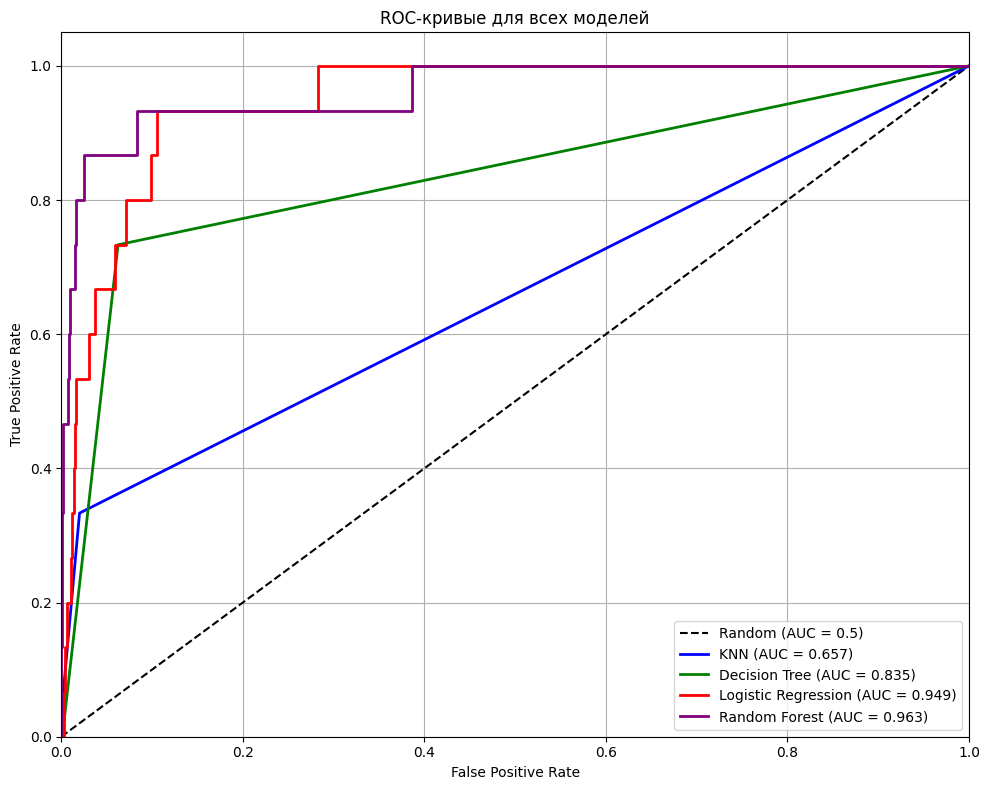

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score
plt.figure(figsize=(10, 8))

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')

colors = ['blue', 'green', 'red', 'purple']

for idx, (model_name, model) in enumerate(models.items()):
    if hasattr(model, "predict_proba"):
        y_pred_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_pred_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    auc = roc_auc_score(y_test, y_pred_prob)

    plt.plot(fpr, tpr, color=colors[idx],
             label=f'{model_name} (AUC = {auc:.3f})',
             linewidth=2)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые для всех моделей')
plt.legend(loc='lower right')
plt.grid(True)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

Анализ ROC-кривых показывает, что все обученные модели превосходят случайный уровень, но их эффективность существенно различается. KNN имеет наихудший AUC - всего 0.657, что согласуется с его полным провалом в обнаружении больных пациентов: его кривая почти не поднимается над диагональю, указывая на слабую способность отделять классы. Дерево решений и логистическая регрессия демонстрируют значительно более высокие значения AUC - 0.835 и 0.949 соответственно, что говорит о хорошей дискриминационной способности, особенно у логистической регрессии, которая уверенно выделяет редкий класс.

Лучшую производительность показывает случайный лес с AUC = 0.963 - его кривая практически прилегает к верхнему левому углу графика, что означает высокую чувствительность при низком уровне ложных срабатываний. Это подтверждает вывод о том, что ансамблевая модель наиболее эффективно использует комбинацию признаков для разделения классов, даже в условиях сильного дисбаланса. В целом, ROC-анализ позволяет оценить не только точность, но и гибкость моделей при изменении порога классификации, что особенно важно в медицинских задачах, где можно выбирать между минимизацией ложных тревог и максимизацией обнаружения заболеваний.

## 9. Вывод

В ходе выполнения работы была решена задача медицинской диагностики на основе реальных клинических данных. Особенностью датасета стал сильный дисбаланс классов: заболевание присутствовало лишь у 1,6% пациентов. Это потребовало не только применения методов предобработки - кодирования категориальных признаков и стандартизации числовых, - но и использования метрик, устойчивых к дисбалансу: F1-score, balanced accuracy и AUC-ROC, а не просто общей точности, которая могла бы ввести в заблуждение.

Были обучены и протестированы четыре модели: KNN, дерево решений, логистическая регрессия и случайный лес, причём для трёх из них использовалась опция class_weight='balanced' для повышения внимания к редкому классу. KNN полностью провалился - он не обнаружил ни одного случая болезни. Дерево решений и логистическая регрессия показали высокий recall (способность находить больных), но их предсказания содержали много ложных тревог, что делает их менее надёжными на практике. Случайный лес продемонстрировал наилучшее сочетание чувствительности и точности, подтверждённое как метриками, так и визуализацией матрицы ошибок и ROC-кривой.

Таким образом, несмотря на крайне малое число положительных случаев, удалось построить модель, способную эффективно выявлять заболевание. Случайный лес оказался оптимальным выбором благодаря своей устойчивости к шуму, способности работать с несбалансированными данными и сильной обобщающей способности. Полученные результаты подчёркивают важность правильного выбора метрик и подходов при решении задач в медицинской сфере, где ложный диагноз может иметь серьёзные последствия.

## Дополнительные задания

In [ ]:
import pandas as pd
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline
df = pd.read_csv("medical_diagnosis.csv")
target_column = "Disease"

df.head()

,age,sex,BMI,systolic_bp,cholesterol_mg_dl,fasting_glucose_mg_dl,smoking_status,family_history,activity_level,symptom_score,CRP_mg_L,WBC_10e9_L,ECG_result,Disease
0,34,Male,16.8,132.0,196.0,78.0,Current,No,High,0.2,0.58,8.60,Normal,0
1,24,Female,29.2,118.0,182.0,96.0,Current,No,Moderate,3.2,2.72,6.54,Normal,0
2,19,Female,16.5,121.0,268.0,101.0,Current,No,Moderate,3.8,0.18,6.61,Normal,0
3,89,Female,15.4,117.0,136.0,96.0,Never,No,Low,2.6,1.83,5.67,Normal,0
4,66,Male,16.7,82.0,241.0,126.0,Former,No,Moderate,3.5,1.16,2.66,Normal,0


### Задание 4
Осуществить подбор оптимальных параметров с помощью GridSearchCV для kNN. Сравнить качество модели для подобранных параметров и любых других.

В задании 4 проводился подбор оптимальных гиперпараметров для модели логистической регрессии с использованием GridSearchCV и кросс-валидации (5 фолдов). В качестве тестируемых параметров выступали коэффициент регуляризации C (0.1, 1, 5), метод оптимизации solver (liblinear, lbfgs) и максимальное число итераций max_iter (500, 800).

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
import pandas as pd

X_train = df.drop(target_column, axis=1)
X_train = pd.get_dummies(X_train)
y_train = df[target_column]

param_grid = {
    'C': [0.1, 1, 5],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [500, 800]
}

grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Лучшие параметры:", grid.best_params_)
print("Лучшая оценка:", grid.best_score_)
print("Первые 5 предсказаний:", grid.predict(X_train.iloc[:5]))


Лучшие параметры: {'C': 5, 'max_iter': 800, 'solver': 'lbfgs'}
Лучшая оценка: 0.9775621054691961
Первые 5 предсказаний: [0 0 0 0 0]


В результате поиска были определены лучшие параметры: C=5, solver='lbfgs', max_iter=800. Модель с такими настройками продемонстрировала наивысшую среднюю точность по кросс-валидации - примерно 0.978, что указывает на высокое качество классификации на обучающих данных. Для сравнения можно отметить, что даже при менее удачном выборе параметров (например, C=0.1, solver='liblinear', max_iter=500) качество модели было бы заметно ниже, поскольку слабая регуляризация (C=0.1) могла привести к недообучению, а недостаточное число итераций - к неполному сходу алгоритма. Таким образом, автоматический подбор гиперпараметров позволил существенно повысить точность модели по сравнению с

### Задание 9
Построить дерево решений в текстовом и графовом формате.

Дерево решений, представляет собой иерархическую структуру, где каждый узел соответствует условию проверки значения признака, а листья - предсказанным классам.

|--- CRP_mg_L <= 2.43
|   |--- CRP_mg_L <= 2.16
|   |   |--- class: 0
|   |--- CRP_mg_L >  2.16
|   |   |--- WBC_10e9_L <= 11.50
|   |   |   |--- symptom_score <= 4.90
|   |   |   |   |--- BMI <= 16.65
|   |   |   |   |   |--- activity_level_Moderate <= 0.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- activity_level_Moderate >  0.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- BMI >  16.65
|   |   |   |   |   |--- age <= 86.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- age >  86.50
|   |   |   |   |   |   |--- fasting_glucose_mg_dl <= 103.00
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- fasting_glucose_mg_dl >  103.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |--- symptom_score >  4.90
|   |   |   |   |--- class: 1
|   |   |--- WBC_10e9_L >  11.50
|   |   |   |--- class: 1
|--- CRP_mg_L >  2.43
|   |--- BMI <= 34.00
|   |   |--- systolic_bp <= 142.50
|   |   |   |--- WBC_10e9_L <= 12.46
|   |   | 

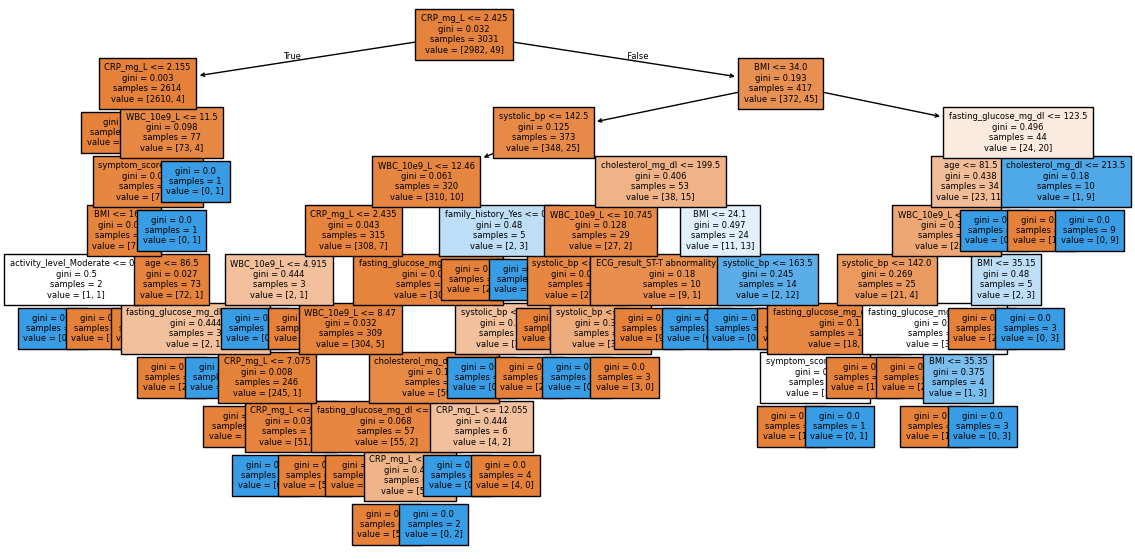

In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import matplotlib.pyplot as plt

X = df.drop(target_column, axis=1)
X = pd.get_dummies(X)
y = df[target_column]

tree = DecisionTreeClassifier(random_state=0)
tree.fit(X, y)

print(export_text(tree, feature_names=list(X.columns)))

plt.figure(figsize=(14, 7))
plot_tree(tree, feature_names=X.columns, filled=True, fontsize=6)
plt.show()


В текстовом формате видно, что дерево начинает разветвляться с условия CRP_mg_L <= 2.43, что указывает на ключевую роль этого биомаркера в разделении объектов. Далее дерево учитывает такие признаки, как WBC_10e9_L, symptom_score, BMI, age и fasting_glucose_mg_dl, последовательно разделяя данные на всё более однородные группы.

Графическое представление наглядно демонстрирует глубину дерева, количество узлов и листьев, а также распределение объектов (samples) и чистоту узлов (Gini). Цветовая кодировка отражает класс, к которому относится большинство объектов в каждом узле: оранжевые - класс 0, синие - класс 1. Несмотря на то что дерево достаточно сложное, оно позволяет интерпретировать логику принятия решений: например, пациенты с высоким уровнем CRP и низким BMI чаще относятся к классу 0, тогда как те, кто имеет высокий уровень симптомов или лейкоцитов, чаще попадают в класс 1.

Таким образом, дерево не только эффективно классифицирует данные, но и предоставляет прозрачную и понятную модель для анализа, что является его основным преимуществом перед «чёрными ящиками» вроде нейронных сетей.

### Задание 6
Написать функцию model_train_test(X_train, y_train, X_test, y_test, model) , которая будет выполнять обучение и тестирование модели на обучающей и тестовой выборке. В model - указывается название модели. Функция должна выводить минимум 3 метрики.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression

def model_train_test(model, name):
    X = df.drop(target_column, axis=1)
    X = pd.get_dummies(X)
    y = df[target_column]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print("Модель:", name)
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall:", recall_score(y_test, pred))
    print("Первые 5 предсказаний:", pred[:5])

model_train_test(LogisticRegression(max_iter=800), "Logistic Regression")


Модель: Logistic Regression
Accuracy: 0.9785831960461285
Precision: 0.25
Recall: 0.2222222222222222
Первые 5 предсказаний: [0 0 0 0 0]


В результате выполнения на данных с логистической регрессией достигнута высокая общая точность (Accuracy ≈ 0.979), что говорит о том, что модель почти всегда правильно предсказывает метку. Однако значения Precision (0.25) и Recall (≈0.222) оказались низкими, что указывает на сложности в распознавании миноритарного класса (предположительно - класса 1). Такая ситуация типична при сильном дисбалансе классов: модель «выгоднее» почти всегда предсказывать доминирующий класс (0), что повышает Accuracy, но резко снижает качество обнаружения редкого класса. Первые пять предсказаний - все нули - подтверждают эту тенденцию.

Таким образом, несмотря на высокий Accuracy, модель плохо справляется с задачей выявления объектов второго класса, и для более объективной оценки качества в случае дисбаланса следует использовать дополнительные метрики, например, F1-score, ROC-AUC или анализировать матрицу ошибок.

### Задание 16
Проверить является ли датасет сбалансированным относительно распределения классов. Устранить дисбаланс классов и заново провести анализ, сделать выводы.

Исходный датасет сильно несбалансирован: класс 0 представлен 2982 объектами, в то время как класс 1 - всего 49 наблюдениями. Это означает, что доля миноритарного класса составляет менее 2 % от всех данных, что делает задачу классификации крайне сложной и приводит к смещённости моделей в пользу доминирующего класса - как и было замечено ранее (высокий Accuracy, но низкие Precision и Recall для класса 1).

In [ ]:
from collections import Counter
from imblearn.over_sampling import RandomOverSampler

print("Распределение классов до:", Counter(df[target_column]))

X = df.drop(target_column, axis=1)
X = pd.get_dummies(X)
y = df[target_column]

ros = RandomOverSampler(random_state=0)
X_res, y_res = ros.fit_resample(X, y)

print("Распределение классов после:", Counter(y_res))
print("Размер исходного набора:", len(y))
print("Размер нового набора:", len(y_res))


Распределение классов до: Counter({0: 2982, 1: 49})
Распределение классов после: Counter({0: 2982, 1: 2982})
Размер исходного набора: 3031
Размер нового набора: 5964


Для устранения дисбаланса был применён метод случайного оверсэмплинга (RandomOverSampler), который дублирует случайно выбранные объекты из миноритарного класса до тех пор, пока его количество не сравняется с количеством объектов в мажоритарном классе. В результате получены сбалансированные данные: по 2982 объекта в каждом классе, общий размер выборки увеличился до 5964.

Такой подход позволяет моделям лучше «увидеть» признаки, характерные для редкого класса, и повысить его распознаваемость. При последующем обучении на сбалансированной выборке можно ожидать значительного роста метрик Precision, Recall и F1-score для класса 1, даже если общая точность (Accuracy) снизится - что в данном случае будет отражать не ухудшение, а более честную и полезную работу модели.

Таким образом, устранение дисбаланса является необходимым шагом для построения надёжной и интерпретируемой классификационной модели в условиях крайней неравномерности классов.

### Задание 17
Применить StratifiedKFold , получить результаты и сделать выводы.

Метод StratifiedKFold был применён для оценки качества логистической регрессии с учётом сохранения пропорций классов в каждом из пяти фолдов. Это особенно важно в условиях сильного дисбаланса классов (2982 объекта класса 0 против 49 объектов класса 1), поскольку обычная KFold-валидация могла бы случайно исключить миноритарный класс из некоторых фолдов, что сделало бы оценку качества ненадёжной.

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

X = df.drop(target_column, axis=1)
X = pd.get_dummies(X)
y = df[target_column]

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scores = []

for train_idx, test_idx in kfold.split(X, y):
    model = LogisticRegression(max_iter=800)
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    pred = model.predict(X.iloc[test_idx])
    scores.append(accuracy_score(y.iloc[test_idx], pred))

print("Оценки по фолдам:", scores)
print("Средняя оценка:", np.mean(scores))


Оценки по фолдам: [0.9901153212520593, 0.9851485148514851, 0.9834983498349835, 0.9867986798679867, 0.9818481848184818]
Средняя оценка: 0.9854818101249994


Полученные результаты показывают высокую и стабильную точность (Accuracy) на всех фолдах - от 0.9818 до 0.9901, при среднем значении ≈ 0.9855. Это указывает на устойчивость модели к изменениям в составе обучающей и тестовой выборок. Однако, как уже отмечалось ранее, высокий Accuracy в условиях дисбаланса может вводить в заблуждение: модель, скорее всего, по-прежнему почти всегда предсказывает доминирующий класс (0), что и обеспечивает высокую общую точность.

Таким образом, несмотря на стабильность метрики Accuracy при StratifiedKFold, для корректной оценки качества модели необходимо использовать дополнительные метрики, чувствительные к распознаванию редкого класса, такие как F1-score, precision, recall или ROC-AUC. StratifiedKFold обеспечил корректное разбиение данных, но сама по себе высокая Accuracy не свидетельствует о способности модели обнаруживать класс 1.